# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

> Initial imports and setting magics:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Part 1: Inequality in Denmark

> Loading data from Statistics Denmark's tables IFOR41 and IFOR32:

In [34]:
#data = dataproject.load_data()

# Downloading tables data
from dstapi import DstApi

# IFOR41 setup
ifor41_api = DstApi('IFOR41')

params_41 = {
    'table': 'ifor41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}
    ]
}

ifor41 = ifor41_api.get_data(params=params_41)

ifor41_df = pd.DataFrame(ifor41)
# Sorting by year
ifor41_df['INDHOLD'] = ifor41_df['INDHOLD'].astype(float)
ifor41_df['TID'] = pd.to_numeric(ifor41_df['TID'])
ifor41_df = ifor41_df.sort_values(by='TID').reset_index(drop=True)

ifor41_df.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,1987,22.07
1,Gini coefficient,All Denmark,1988,22.06
2,Gini coefficient,All Denmark,1989,21.93
3,Gini coefficient,All Denmark,1990,22.16
4,Gini coefficient,All Denmark,1991,21.99


In [110]:
#IFOR32 setup
ifor32_api = DstApi('IFOR32')

params_32 = {
    'table': 'ifor32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}
    ]
}

ifor32 = ifor32_api.get_data(params=params_32)

ifor32_df = pd.DataFrame(ifor32)
# Sorting
ifor32_df['INDHOLD'] = ifor32_df['INDHOLD'].astype(float)
ifor32_df['TID'] = pd.to_numeric(ifor32_df['TID'])
ifor32_df = ifor32_df.sort_values(by=['TID']).reset_index(drop=True)

ifor32_df.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,1987,31418.0
1,Ninth decil,All Denmark,1987,123582.0
2,Eigth decil,All Denmark,1987,110184.0
3,Seventh decil,All Denmark,1987,100691.0
4,Sixth decil,All Denmark,1987,92777.0


> 1.1: The Gini coefficient and the top 10 percent share

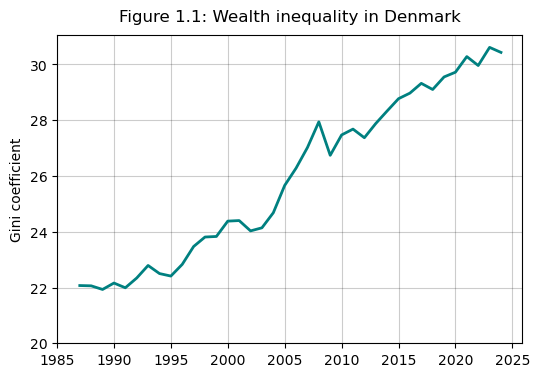

In [162]:
# Plotting figure from DataFrame ifor41_df
fig_41 = plt.figure(
    figsize=(6,4),
    facecolor='white',
)
ax_41 = fig_41.add_subplot(1,1,1)

ax_41.plot(ifor41_df['TID'], ifor41_df['INDHOLD'], label='GINI', linestyle='-', linewidth='2', color='teal', zorder=10)
ax_41.set_xticks(np.arange(1985,2025+1,5))
ax_41.set_yticks(np.arange(20, 32, 2))

ax_41.grid(True, color='black', alpha=0.2)
ax_41.set_title('Figure 1.1: Wealth inequality in Denmark', pad=10)
ax_41.set_ylabel('Gini coefficient')
plt.show()

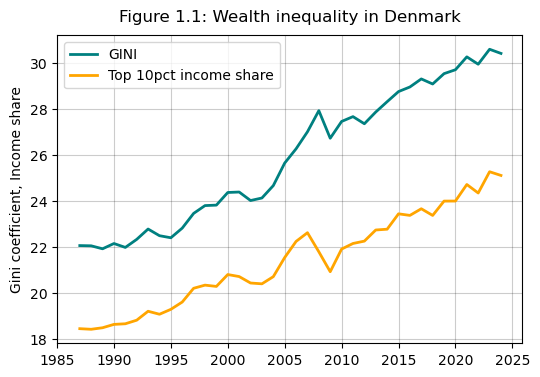

In [ ]:
# Using table IFOR32, add the share of total income going to the richest 10 percent.
# Hint II: IFOR32 reports the average income within each decile group. Since every 
# decile group contains the same number of people, the income share of the top decile is:

# Calculate total avg income every year
total_decile_list = []
for decile in range(0, len(ifor32_df['INDHOLD']), 10):
    sumdecile = sum(ifor32_df['INDHOLD'][decile:decile + 10])
    total_decile_list.append(sumdecile)

# getting np.array of tenth decile
finding_10thdecile = np.where(np.array(ifor32_df[['DECILGEN']]=='Tenth decil'))
#copied from printing above
placement_10thdecile = np.array([  9,  12,  28,  30,  46,  58,  64,  70,  89,  90, 102, 118, 121,
       138, 149, 151, 162, 171, 180, 198, 202, 218, 222, 232, 243, 252,
       260, 271, 287, 298, 307, 314, 323, 330, 340, 354, 366, 378])

tenth_deciles_df = ifor32_df.iloc[placement_10thdecile]

tenth_deciles_nocommas = np.array(tenth_deciles_df['INDHOLD'])
tenth_deciles = np.array([169598, 178357, 188967, 197793, 207208, 215250, 226495, 240502, 253941,
 267669, 286696, 300898, 308395, 329207, 338942, 347627, 356782, 383943,
 416199, 447312, 466484, 446011, 437019, 500012, 516944, 533189, 560961,
 573866, 607665, 615554, 641188, 648231, 688377, 719999, 779827, 769052,
 834074, 852980,])

total_decile = np.array(total_decile_list)

incomeshare_top10 = tenth_deciles / total_decile

# Add results to figure 1.1
fig_32 = plt.figure(
    figsize=(6,4),
    facecolor='white',
)
ax_32 = fig_32.add_subplot(1,1,1)

ax_32.plot(ifor41_df['TID'], ifor41_df['INDHOLD'], label='GINI', linestyle='-', linewidth='2', color='teal', zorder=10)
ax_32.plot(ifor41_df['TID'], incomeshare_top10*100, label='Top 10pct income share', linestyle='-', linewidth='2', color='orange', zorder=5)
ax_32.set_xticks(np.arange(1985,2025+1,5))
ax_32.set_yticks(np.arange(18, 32, 2))

ax_32.grid(True, color='black', alpha=0.2)
ax_32.set_title('Figure 1.1: Wealth inequality in Denmark', pad=10)
ax_32.set_ylabel('Gini coefficient, Income share')

ax_32.legend()
plt.show()

In [440]:
# Correlation
correlation = ifor41_df['INDHOLD'].corr(tenth_deciles_df['INDHOLD'])
print('Correlation is: ' + str(correlation))

Correlation is: 0.9572540180507504


<p> Both the Gini coefficient and the richest 10 percent's income share have <br>
increased a relatively great amount (almost a 10 percent-point increase in both) </p>

<p> Based on the final figure 1.1 and above calculated correlation, <br>
it appears to be the case that the Gini coefficient and <br>
the richest 10 percent's income share are highly correlated (almost 1:1).</p>

<p> They both signify an increase in the wealth distribution between the Danes, <br>
with the Gini coefficient showing a general decrease in equal distribution between the <br>
ten deciles of the population, where the increase in the 10 percent richest people's income share <br>
may have played a significant part. Especially when taking the correlation between the two <br>
into account.</p>

> 1.2: Prediction

In [298]:
# Using scipy

from scipy import optimize

gini_values = np.array(ifor41_df['INDHOLD'])
year_values = np.arange(len(gini_values)) # so they match above

year_2030 = 2030 - 1987
year_2040 = 2040 - 1987

# Making the initial function to be minimized
def S(beta, y, t, p):
    """
    beta: coefficients
    y: gini_values
    t: year_values
    p: degree of the polynomial
    """
    prediction = np.zeros_like(t, dtype=float)
    for k in range(p + 1): #p=1 is linear, and p=2 is quadratic
        prediction += beta[k] * (t**k)

    return np.sum((y - prediction)**2)

# Linear trend
initial_beta_l = np.array([gini_values[0], 0]) #(b, a) of a linear function, l for linear
l_result = optimize.minimize(S, initial_beta_l, args=(year_values, gini_values, 1), method='SLSQP', bounds=[(0,100)]) # bounds for 'realism'
l_beta = l_result.x

l_prediction2030 = sum(l_beta[k] * (year_2030 ** k) for k in range(1 + 1))
l_prediction2040 = sum(l_beta[k] * (year_2040 ** k) for k in range(1 + 1))

# Quadratic trend
initial_beta_q = np.array([gini_values[0], 0, 0]) #(b, a) of a linear function, l for linear
q_result = optimize.minimize(S, initial_beta_q, args=(year_values, gini_values, 2), method='SLSQP', bounds=[(0,100)])
q_beta = q_result.x

q_prediction2030 = sum(q_beta[k] * (year_2030 ** k) for k in range(2 + 1))
q_prediction2040 = sum(q_beta[k] * (year_2040 ** k) for k in range(2 + 1))

print(f'The linear trend using scipy yields: {l_prediction2030:.2f} in 2030 and {l_prediction2040:.2f} in 2040')
print(f'The quadratic trend using scipy yields: {q_prediction2030:.2f} in 2030 and {q_prediction2040:.2f} in 2040')

The linear trend using scipy yields: 32.31 in 2030 and 39.82 in 2040
The quadratic trend using scipy yields: 18.50 in 2030 and 18.50 in 2040


In [304]:
# Using np.polyfit

l_beta_pf = np.polyfit(year_values, gini_values, 1)[::-1]
q_beta_pf = np.polyfit(year_values, gini_values, 2)[::-1]

def pf_predict(beta, predictedyear):
    return sum(beta[k] * (predictedyear ** k) for k in range(len(beta)))

l_pf_2030 = pf_predict(np.array(l_beta_pf), year_2030)
l_pf_2040 = pf_predict(np.array(l_beta_pf), year_2040)

q_pf_2030 = pf_predict(np.array(q_beta_pf), year_2030)
q_pf_2040 = pf_predict(np.array(q_beta_pf), year_2040)

print(f'The linear trend using polyfit yields: {l_pf_2030:.2f} in 2030 and {l_pf_2040:.2f} in 2040')
print(f'The quadratic trend using polyfit yields: {q_pf_2030:.2f} in 2030 and {q_pf_2040:.2f} in 2040')
print('')
print(f'The linear trend using scipy yields: {l_prediction2030:.2f} in 2030 and {l_prediction2040:.2f} in 2040')
print(f'The quadratic trend using scipy yields: {q_prediction2030:.2f} in 2030 and {q_prediction2040:.2f} in 2040')
print(f'The betas are respectively {l_beta} and {q_beta} using scipy (linear and quadratic), and {l_beta_pf} and {q_beta_pf} using polyfit (same order).')

The linear trend using polyfit yields: 32.38 in 2030 and 35.01 in 2040
The quadratic trend using polyfit yields: 32.94 in 2030 and 36.27 in 2040

The linear trend using scipy yields: 32.31 in 2030 and 39.82 in 2040
The quadratic trend using scipy yields: 18.50 in 2030 and 18.50 in 2040
The betas are respectively [0.         0.75133115] and [18.49999939  0.          0.        ] using scipy (linear and quadratic), and [21.04275304  0.26354962] and [2.13042004e+01 2.19975061e-01 1.17769085e-03] using polyfit (same order).


<p> While adding bounds to the method using scipy yielded more reasonable results, <br>
there is still relatively substantial differences between using scipy and polyfit, especially in the beta values. <br>
Between the linear and quadratic trend within the same method, there is fewer differences in the polyfit<br>
compared to the scipy method. However, aside from the quadratic trend using scipy<br>
the predictions for Gini coefficient in 2030 and 2040 tend toward similar values, and an increasing<br>
wealth disparity in Denmark.
</p>

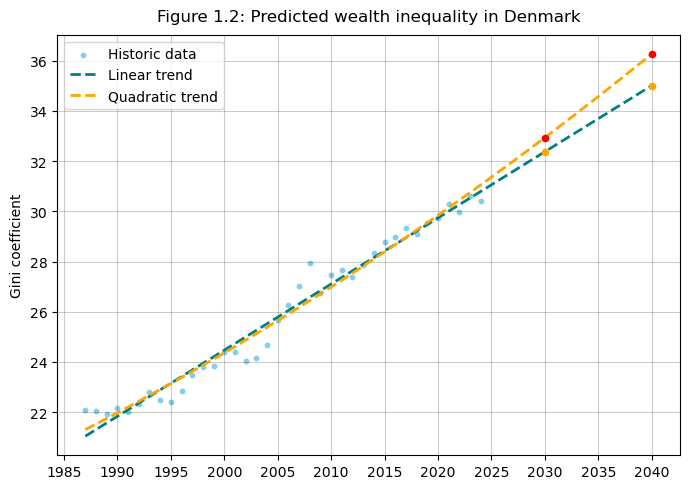

In [361]:
# Using the estimates in predicting the Gini coefficient in 2030 and 2040
final_2030_l = l_beta_pf[0] + l_beta_pf[1]*year_2030
final_2040_l = l_beta_pf[0] + l_beta_pf[1]*year_2040

final_2030_q = q_beta_pf[0] + q_beta_pf[1]*year_2030 + q_beta_pf[2]*(year_2030**2)
final_2040_q = q_beta_pf[0] + q_beta_pf[1]*year_2040 + q_beta_pf[2]*(year_2040**2)

# Plotting the result
future = np.arange(0, 2040 - 1987 + 1)
years_future = 1987 + future

fig_gini, ax_gini = plt.subplots(
    figsize=(7,5)
    )

plt.scatter(ifor41_df['TID'], ifor41_df['INDHOLD'], color='skyblue', marker='o', s=10, zorder=0, label='Historic data')

ax_gini.plot(years_future, l_beta_pf[0] + l_beta_pf[1]*future, label='Linear trend', linestyle='--', linewidth='2', color='teal')
ax_gini.plot(years_future, q_beta_pf[0] + q_beta_pf[1]*future + q_beta_pf[2]*(future**2), label='Quadratic trend', linestyle='--', linewidth='2', color='orange')
ax_gini.set_xticks(np.arange(1985,2040+1,5))
ax_gini.set_yticks(np.arange(18, 40, 2))

plt.scatter([2030, 2040], [final_2030_l, final_2040_l], color='orange', marker='o', s=20, zorder=6)
plt.scatter([2030, 2040], [final_2030_q, final_2040_q], color='red', marker='o', s=20, zorder=6)

ax_gini.grid(True, color='black', alpha=0.2)
ax_gini.set_title('Figure 1.2: Predicted wealth inequality in Denmark', pad=10)
ax_gini.set_ylabel('Gini coefficient')

ax_gini.legend()
fig_gini.tight_layout()
plt.show()

<p> As the trendlines head further into the future, the difference between the predictions grows,<br>
which, at least in part, can be attributed to the uncertainty of the future, and their<br>
different polynomial structures.
</p>
<p> There is more of a steep slope on the quadratic trendline, however, <br>
the linear trendline seems to align sligtly more with the historical data slope-wise.<br>
The linear trendline therefore seems more accurate, along with the slope making for<br>
more conservative estimations.
</p>

> 1.3: Municipalities

In [443]:
# Initial setup
ifor41_api_m = DstApi('IFOR41')

params_41_m = {
    'table': 'ifor41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'TID', 'values': ['*']}
    ]
}

ifor41_m = ifor41_api_m.get_data(params=params_41_m)

ifor32_api_m = DstApi('IFOR32')

params_32_m = {
    'table': 'ifor32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'TID', 'values': ['*']}
    ]
}

ifor32_m = ifor32_api_m.get_data(params=params_32_m)

#Excluding 'Hele landet' from the data
def filter_municipalities(df): #df = dataframe
    exclude_this = ['Hele landet', 'All Denmark']
    filtered_df = df[~df['KOMMUNEDK'].isin(exclude_this)].copy()
    return filtered_df


ifor41_df_m = filter_municipalities(ifor41_m)
ifor32_df_m = filter_municipalities(ifor32_m)

#Sorting deciles

df_pivot_decil = ifor32_df_m.pivot_table(
    index=['KOMMUNEDK', 'TID'],
    columns='DECILGEN',
    values='INDHOLD').reset_index()

decil_columns = ['First decil', 'Second decil', 'Third decil', 'Fourth decil', 'Fifth decil',
                 'Sixth decil', 'Seventh decil', 'Eigth decil', 'Ninth decil', 'Tenth decil']
df_pivot_decil['Decils_summed'] = df_pivot_decil[decil_columns].sum(axis=1)

df_pivot_decil['top10pct_share'] = df_pivot_decil['Tenth decil'] / df_pivot_decil['Decils_summed']

# Merge top10pct_share with ifor41
gini_merge = pd.merge(
    ifor41_df_m[['KOMMUNEDK', 'TID', 'INDHOLD']],
    df_pivot_decil[['KOMMUNEDK', 'TID', 'top10pct_share']],
    on=['KOMMUNEDK', 'TID']
)

# Correlation across municipalities

gini_merge['INDHOLD'] = pd.to_numeric(gini_merge['INDHOLD'], errors='coerce')
gini_merge['top10pct_share'] = pd.to_numeric(gini_merge['top10pct_share'], errors='coerce')
gini_merge_numbers = gini_merge.dropna(subset=['INDHOLD', 'top10pct_share'])

#gini_merge['INDHOLD'] = gini_merge['INDHOLD'].astype(float)
gini_merge['top10pct_share'] = gini_merge['top10pct_share'].astype(float)
gini_merge['TID'] = pd.to_numeric(ifor32_df['TID'])
gini_merge = gini_merge.sort_values(by=['TID']).reset_index(drop=True)

municipality_corr = []

for m in sorted(gini_merge_numbers['KOMMUNEDK'].unique()):
    df_m = gini_merge_numbers[gini_merge_numbers['KOMMUNEDK'] == m]

    correlation = ifor41_df_m['INDHOLD'].corr(df_year['top10pct_share'])

    if len(df_m) >= 3:
        corr_value = df_m['INDHOLD'].corr(df_m['top10pct_share'])
    else:
        corr_value = None

    municipality_corr.append({'KOMMUNEDK': m, 'Correlation_over_time': corr_value})

municipality_corr_df = pd.DataFrame(municipality_corr)
m_corr_df_sorted = municipality_corr_df.sort_values(by='Correlation_over_time', ascending=True)
print(m_corr_df_sorted)
print('Mean across individual municipalities: ' + str(m_corr_df_sorted['Correlation_over_time'].mean()))

      KOMMUNEDK  Correlation_over_time
76    Silkeborg               0.778393
57         Læsø               0.856317
10  Brønderslev               0.860064
81         Sorø               0.869034
69       Rebild               0.873490
..          ...                    ...
88       Tårnby               0.992395
42     Hvidovre               0.993170
74      Rødovre               0.993738
9       Brøndby               0.993910
46        Ishøj               0.993964

[98 rows x 2 columns]
Mean across individual municipalities: 0.9474227883756362


<p> It appears to be the case that a high correlation between the ten percent richest people's<br> 
income share and the gini coefficient holds even within municipalities, although<br>
it is now evident that there is some variation, along with a mean that differs slightly to<br>
the before calculated correlation for all of Denmark.
</p>

In [444]:
#Sorting gini_merge_numbers
latest_year = gini_merge_numbers['TID'].max()
df_latest_year = gini_merge_numbers[gini_merge_numbers['TID'] == latest_year].copy()

gini_sorted = df_latest_year.sort_values(by='INDHOLD', ascending=True)

#Making Dataframe for presentation
most_eq_list = [
    f"{row['KOMMUNEDK']} ({row['INDHOLD']:.2f})" 
    for _, row in gini_sorted.head(10).iterrows()
]

least_eq_list = [
    f"{row['KOMMUNEDK']} ({row['INDHOLD']:.2f})" 
    for _, row in gini_sorted.tail(10).iloc[::-1].iterrows()
]

df_eq = pd.DataFrame({
    'Least_Equal': least_eq_list,
    'Most_Equal': most_eq_list
})
df_eq.index = range(1, len(df_eq) + 1)

#Creating table figure

from tabulate import tabulate

print(tabulate(df_eq, headers='keys', tablefmt='simple', showindex='always'))

    Least_Equal             Most_Equal
--  ----------------------  -----------------------
 1  Gentofte (49.04)        Faaborg-Midtfyn (23.77)
 2  Rudersdal (47.31)       Egedal (23.85)
 3  Vejen (46.32)           Bornholm (24.03)
 4  Hørsholm (40.07)        Faxe (24.09)
 5  Lyngby-Taarbæk (39.28)  Halsnæs (24.41)
 6  Frederiksberg (36.54)   Favrskov (24.41)
 7  Copenhagen (34.97)      Assens (24.46)
 8  Aarhus (33.43)          Hedensted (24.58)
 9  Fredensborg (32.76)     Albertslund (24.66)
10  Helsingør (30.55)       Odder (24.70)


<p> There seems to be a pattern of higher degrees of wealth disparities in<br>
'richer' municipalities. 'Richer' here referring to a high output in GVA<br>
along with generally higher disposable incomes. This makes sense, because<br>
the Gini coefficient for the tables IFOR32 and IFOR42 are based on <br>
equivalized disposable income.
</p>

In [445]:
#Sorting
First_year = gini_merge_numbers['TID'].min()
Newest_year = gini_merge_numbers['TID'].max()

df_begin = gini_merge_numbers[gini_merge_numbers['TID'] == First_year][
    ['KOMMUNEDK', 'INDHOLD']].rename(columns={'INDHOLD': 'g_begin'})
df_end = gini_merge_numbers[gini_merge_numbers['TID'] == Newest_year][
    ['KOMMUNEDK', 'INDHOLD']].rename(columns={'INDHOLD': 'g_end'})

#Calculating change and sorting
df_change = pd.merge(df_begin, df_end, on='KOMMUNEDK')
df_change['Change'] = df_change['g_end'] - df_change['g_begin']
df_change['Abs_change'] = df_change['Change'].abs()

Most_c = (
    df_change.sort_values(by='Abs_change', ascending=False)
    .head(10).reset_index(drop=True)
)
Least_c = (
    df_change.sort_values(by='Abs_change', ascending=True)
    .head(10).reset_index(drop=True)
)

#Making Dataframe for presentation
most_c_list = [
    f"{row['KOMMUNEDK']} ({row['Change']:+.2f})" 
    for _, row in Most_c.iterrows()
]

least_c_list = [
    f"{row['KOMMUNEDK']} ({row['Change']:+.2f})" 
    for _, row in Least_c.iterrows()
]

df_c = pd.DataFrame({
    'Least_Change': least_c_list,
    'Most_Change': most_c_list
})
df_c.index = range(1, len(df_c) + 1)

#Creating table figure
print(tabulate(df_c, headers='keys', tablefmt='simple', showindex='always'))

    Least_Change             Most_Change
--  -----------------------  -----------------------
 1  Fanø (+0.67)             Vejen (+25.12)
 2  Ærø (+2.35)              Rudersdal (+18.26)
 3  Faxe (+2.45)             Gentofte (+17.94)
 4  Læsø (+2.60)             Lyngby-Taarbæk (+14.31)
 5  Bornholm (+2.72)         Copenhagen (+11.92)
 6  Faaborg-Midtfyn (+2.89)  Hørsholm (+11.68)
 7  Sorø (+2.92)             Fredensborg (+11.59)
 8  Stevns (+3.42)           Aarhus (+11.33)
 9  Mariagerfjord (+3.67)    Frederiksberg (+11.26)
10  Odder (+3.77)            Vallensbæk (+10.80)


<p> There seems to be a pattern of the same municipalities in the top<br>
ten least equal appearing in the top ten municipalities with the most change in<br>
their wealth disparities, and vice versa. Once again this can be partly<br>
due to aforementioned factors.
</p>

> 1.4: Extension

In [46]:
# Find some other information at the municipality level and relate it to the level of the
# Gini coefficient or to its change over time.
# Note: This is intended as an open question, and we encourage you to be creative.

### Part 2: Simulating the income distribution

> 2.1: Setting up the model

In [ ]:
#data = dataproject.process_data(data)

# Setup
rng_life = np.random.default_rng(340) #340 = EDO, as in EDU

N = 50000 # Number of individuals
p_e = (0.40, 0.35, 0.25) # Education probabilities
S_e = (1, 3, 5) #Years of education
h_e0 = (1.00, 1.20, 1.55) # Initial human capital
delta_e = (0.010, 0.020, 0.030) # Growth of human capital
lcdelta = 0.06 # Depreciation while unemployed, lc for lowercase
lcsigma_psi = 0.10 # Standard deviation of shock
Lambda = 0.60 # Job-finding probability
lcsigma = 0.05 #Job-separation probability
y_SU = 0.45 # Student grant
rho = 0.60 # Replacement rate
y_lbar = 0.35 # Benefit floor

In [492]:
#Making the model

class LifeCycle_sim:
    def __init__(self, N=50000, seed=340):
        self.rng = np.random.default_rng(seed)
        self.N = N

        # Age setup
        self.age_start = 18
        self.age_stop = 65
        self.T = self.age_stop - self.age_start # Rounds

        # Model parameters
        # Education
        self.pe = [0.40, 0.35, 0.25]
        self.se = {'short': 1, 'medium': 3, 'long': 5}
        self.he0 = {'short': 1.00, 'medium': 1.20, 'long': 1.55}
        self.delta_e = {'short': 0.010, 'medium': 0.020, 'long': 0.030}
        self.ysu = 0.45

        # Labor market
        self.lcdelta = 0.06
        self.sigmapsi = 0.10
        self.lam = 0.60
        self.lcsigma = 0.05
        self.rho = 0.60
        self.ylbar = 0.35

    def simulation(self):
        # Education stats
        edu_types = ['short', 'medium', 'long']
        edu_rng = self.rng.choice([0, 1, 2], size=self.N, p=self.pe)

        self.years_in_edu = np.array([self.se[edu_types[i]] for i in edu_rng])
        self.hc_init = np.array([self.he0[edu_types[i]] for i in edu_rng])
        self.hc_gr = np.array([self.delta_e[edu_types[i]] for i in edu_rng])     

        #Individual state, (0: In education, 1: Unemployed, 2: Employed)
        self.status = np.zeros(self.N, dtype=int)
        self.hc = np.zeros(self.N)
        self.y = np.zeros(self.N)
        self.y_last_job = np.zeros(self.N)
        self.ever_employed = np.zeros(self.N, dtype=bool)

        personal_history = {
            'Age': [],
            'Mean_income': [],
            'Employment_rate': [],
            'Unemployment_rate': [],
            'In_education_rate': []
            }

        self.income_history = np.zeros((self.T, self.N))

        # Simulating per year
        for t in range(self.T):
            current_age = self.age_start + t

            # Filter for educational stats
            in_edu = (current_age < self.age_start + self.years_in_edu)
            finished_edu_thisyear = (current_age == self.age_start + self.years_in_edu)
            out_of_edu = (current_age >= self.age_start + self.years_in_edu)

                #Transition from education to labor market
            if np.any(finished_edu_thisyear):
                self.status[finished_edu_thisyear] = 1 # Enter unemployment
                self.hc[finished_edu_thisyear] = self.hc_init[finished_edu_thisyear]

                # Markov chain
            if np.any(out_of_edu):
                unemployed = (self.status == 1) & out_of_edu
                employed = (self.status == 2) & out_of_edu

                # Unemployed --> employed
                found_job = self.rng.random(self.N) < self.lam
                self.status[unemployed & found_job] = 2
                self.ever_employed[unemployed & found_job] = True

                    # Employed --> unemployed
                lost_job = self.rng.random(self.N) < self.lcsigma
                self.status[employed & lost_job] = 1

                # Human capital status
                hc_now = self.rng.lognormal(-0.5 * self.sigmapsi **2, self.sigmapsi, size=self.N)

                # Update the employed
                emp_update = (self.status == 2) & out_of_edu
                self.hc[emp_update] *= (1 + self.hc_gr[emp_update]) * hc_now[emp_update]
                # Update the unemployed
                unemp_update = (self.status == 1) & out_of_edu
                self.hc[unemp_update] *= (1 - self.lcdelta) * hc_now[unemp_update]

                # Income stats
                # While in education
                self.y[in_edu] = self.ysu

                # While employed
                emp_update = (self.status == 2) & out_of_edu
                self.y[emp_update] = self.hc[emp_update]
                self.y_last_job[emp_update] = self.y[emp_update]

                # While unemployed
                unemp_update = (self.status == 1) & out_of_edu
                had_job = unemp_update & self.ever_employed
                never_job = unemp_update & ~self.ever_employed

                self.y[had_job] = self.rho * self.y_last_job[had_job]
                self.y[never_job] = self.ylbar

            self.income_history[t, :] = self.y

            # Collecting data per year
            personal_history['Age'].append(current_age)
            personal_history['Mean_income'].append(self.y.mean())

            # Rates based on labor force/out of education
            labor_force_count = np.sum(out_of_edu)
            if labor_force_count > 0:
                personal_history['Employment_rate'].append(np.sum((self.status == 2) & out_of_edu) / labor_force_count)
                personal_history['Unemployment_rate'].append(np.sum((self.status == 1) & out_of_edu) / labor_force_count)
            else:
                personal_history['Employment_rate'].append(0.0)
                personal_history['Unemployment_rate'].append(0.0)

            personal_history['In_education_rate'].append(np.sum(in_edu) / self.N)
            
        return pd.DataFrame(personal_history)

> 2.2: Simulate the income distribution

In [493]:
# Testrun
sim = LifeCycle_sim()
sim_results = sim.simulation()

# Checking distributions/rates
unique, counts = np.unique(sim.years_in_edu, return_counts=True)
sim_pe = counts / sim.N

print(f'Distributions from simulated education shares: [{sim_pe[0]:.2f}, {sim_pe[1]:.2f}, {sim_pe[2]:.2f}]')
print(f'Given education shares: [{p_e}]')
print('-'*65)

expected_ss = sim.lcsigma / (sim.lcsigma + sim.lam)
sim_ss = sim_results['Unemployment_rate'].iloc[-1]

print(f'Expected steady-state value: {expected_ss*100:.2f}%')
print(f'Simulated steady-state value: {sim_ss*100:.2f}%')

Distributions from simulated education shares: [0.40, 0.35, 0.25]
Given education shares: [(0.4, 0.35, 0.25)]
-----------------------------------------------------------------
Expected steady-state value: 7.69%
Simulated steady-state value: 7.68%


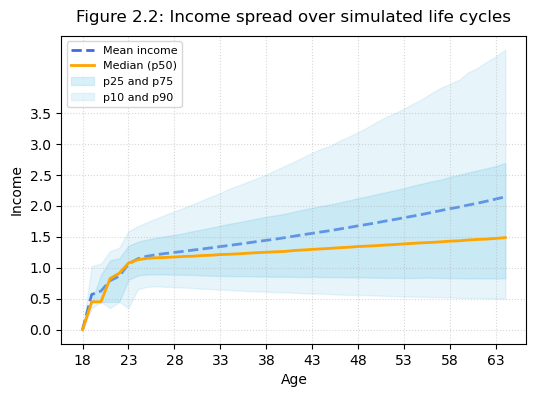

In [513]:
# Setup for percentiles and mean of income over the course of the life cycles
ages = sim_results['Age'].values

mean_income = sim_results['Mean_income'].values
p10 = np.percentile(sim.income_history, 10, axis = 1)
p25 = np.percentile(sim.income_history, 25, axis = 1)
p50 = np.percentile(sim.income_history, 50, axis = 1)
p75 = np.percentile(sim.income_history, 75, axis = 1)
p90 = np.percentile(sim.income_history, 90, axis = 1)

# Plotting figure
fig_simincome = plt.figure(
    figsize=(6,4)
)

plt.plot(ages, mean_income, label='Mean income', color='royalblue', linewidth=2, linestyle='--', zorder=0)
plt.plot(ages, p50, label='Median (p50)', color='orange', linewidth=2)

plt.fill_between(ages, p25, p75, color='skyblue', alpha=0.3, label='p25 and p75')
plt.fill_between(ages, p10, p90, color='skyblue', alpha=0.2, label='p10 and p90')

plt.title('Figure 2.2: Income spread over simulated life cycles', pad=10)
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', fontsize=8, frameon=True)
plt.xticks(np.arange(18,64,5))
plt.yticks(np.arange(0, 4, 0.5))

plt.show()

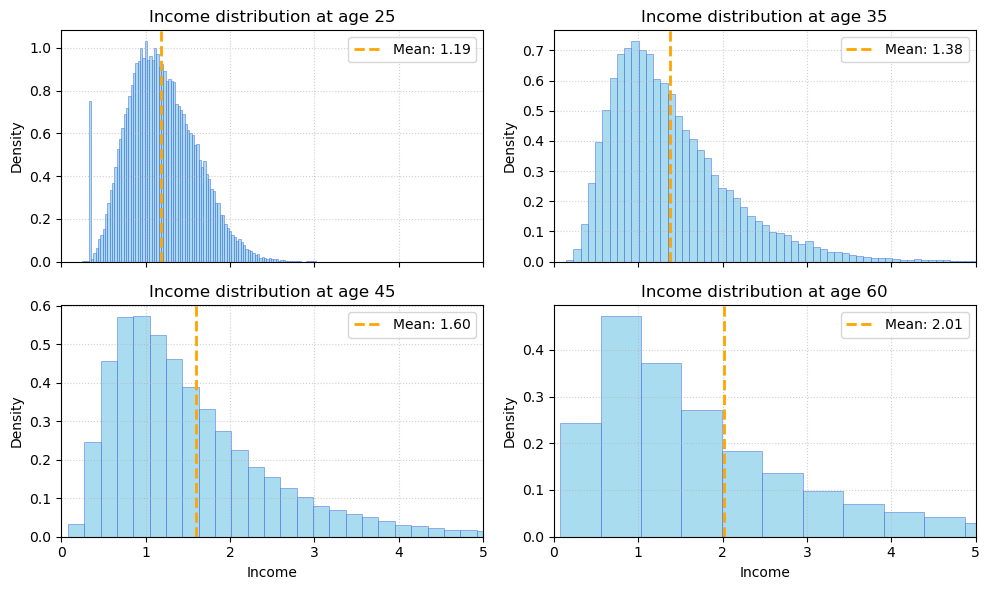

In [ ]:
#3. Plot a histogram of the income distribution at ages 25, 35, 45 and 60, and describe
#how the shape of the distribution changes.

# Setup
ages_list = [25, 35, 45, 60]

# Plotting histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.flatten()

for i, age in enumerate(ages_list):
    t_index = age - sim.age_start

    income_at_age = sim.income_history[t_index, :]

    axes[i].hist(income_at_age, bins=100, density=True, color='skyblue', alpha=0.7, edgecolor='royalblue', linewidth=0.5)
    axes[i].axvline(income_at_age.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {income_at_age.mean():.2f}')
    axes[i].set_xlim(0, 5.0)

    axes[i].set_title(f'Income distribution at age {age}')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='upper right')

axes[2].set_xlabel('Income')
axes[3].set_xlabel('Income')

plt.tight_layout()
plt.show()

<p> In the beginning (until age 35) the distribution of wealth is highly determined by<br>
the peaking of the starting human capital after having finished their education.<br>
Further, the shocks have yet to be able to make much of an impact on the wealth distributions.
</p>
<p> As the individuals age, the shocks to their employment rates and decreasing value<br>
of their human capital that was determined by different educations, start to<br>
accumulate, creating greater wealth disparities and spreads.
</p>
<p>This culminates at the end of their work life before retirement, where<br>
the disparities and spread in income, signifying an advantage of<br>
higher education in the long term along with lucky shocks to ones<br>
employment status.
</p>

> 2.3: Compute the Gini coefficient

> 2.4: What drives inequality

2.5: Extension: More risk

In [48]:
#fig = plt.figure(figsize=(7,4))
#ax = fig.add_subplot(111)

#ax.plot(data['log_GDP'],label='log(GDP)')

#ax.set_title('Log GDP over time')
#ax.set_xlabel('Year')
#ax.set_ylabel('Log GDP')

#ax.legend();